# Task 2: Image Data Collection and Processing

**Goal:** load each group member's 3 submitted face photos (neutral, smiling, surprised), detect and crop the face region, apply augmentations, and extract features into `image_features.csv` for the later Facial Recognition Model.

**Group members / files:** 4 members (M1-M4), 3 raw photos each in `../image_data/`. The `_1/_2/_3` suffix does **not** consistently map to the same expression across members (confirmed by visually inspecting every photo), so the mapping below was built by manual inspection rather than assumed from the filename:

| Member | `_1` | `_2` | `_3` |
|---|---|---|---|
| M1 | surprised | smiling | neutral |
| M2 | smiling | surprised | neutral |
| M3 | neutral | smiling | surprised |
| M4 | neutral | smiling | surprised |

## 1. Load raw images and metadata mapping

In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

IMAGE_DIR = '../image_data'
DATA_DIR = '../data/processed'

# filename (without extension) -> (member, expression), built from manual visual inspection
IMAGE_META = {
    'M1_1': ('M1', 'surprised'),
    'M1_2': ('M1', 'smiling'),
    'M1_3': ('M1', 'neutral'),
    'M2_1': ('M2', 'smiling'),
    'M2_2': ('M2', 'surprised'),
    'M2_3': ('M2', 'neutral'),
    'M3_1': ('M3', 'neutral'),
    'M3_2': ('M3', 'smiling'),
    'M3_3': ('M3', 'surprised'),
    'M4_1': ('M4', 'neutral'),
    'M4_2': ('M4', 'smiling'),
    'M4_3': ('M4', 'surprised'),
}

raw_images = {}
for name in IMAGE_META:
    path = os.path.join(IMAGE_DIR, f'{name}.jpeg')
    img_bgr = cv2.imread(path)
    raw_images[name] = img_bgr
    print(name, '->', img_bgr.shape)


M1_1 -> (1280, 960, 3)
M1_2 -> (1280, 960, 3)
M1_3 -> (1280, 960, 3)
M2_1 -> (1280, 962, 3)
M2_2 -> (1280, 962, 3)
M2_3 -> (1280, 962, 3)
M3_1 -> (1600, 900, 3)
M3_2 -> (1600, 900, 3)
M3_3 -> (1600, 900, 3)
M4_1 -> (649, 777, 3)
M4_2 -> (648, 605, 3)
M4_3 -> (572, 596, 3)


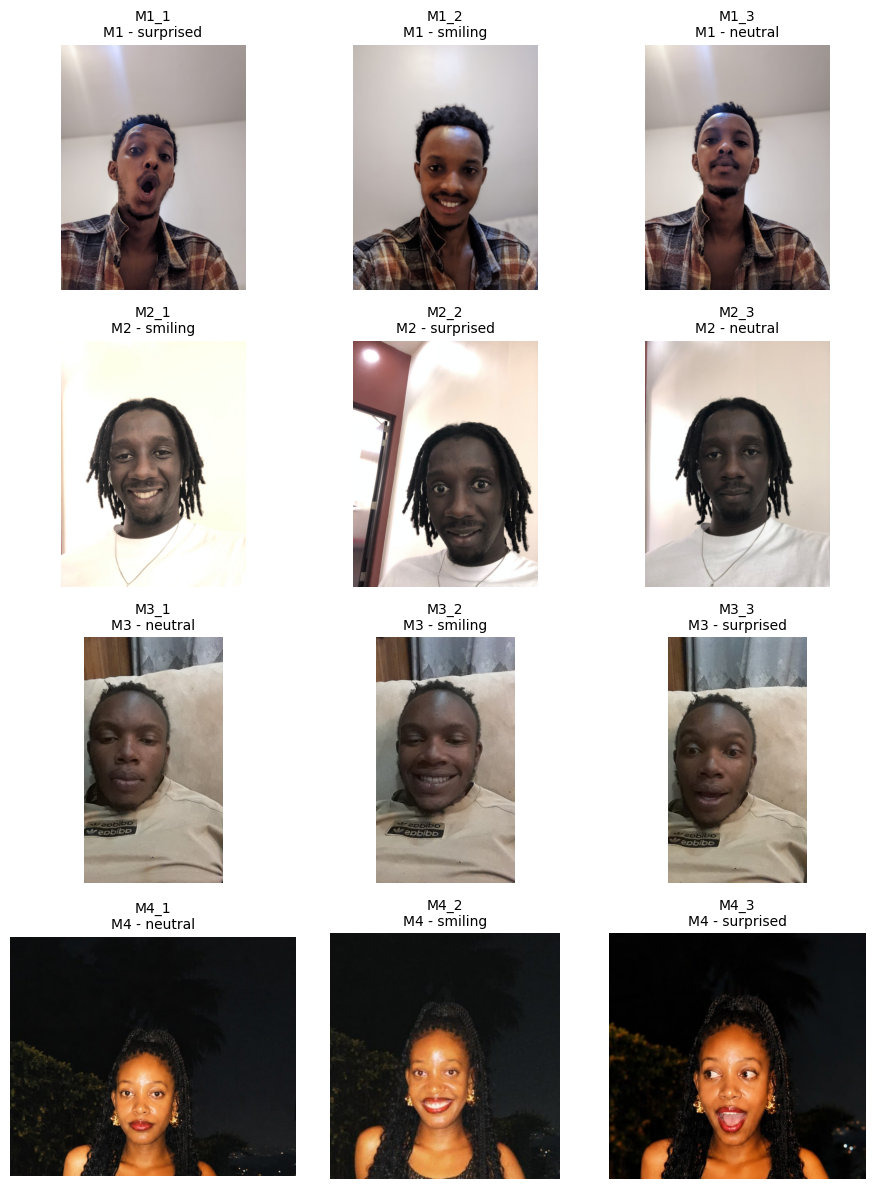

In [2]:
def show_grid(images_dict, titles_fn, ncols=3, figsize_per_cell=(3,3), cmap=None):
    names = list(images_dict.keys())
    nrows = int(np.ceil(len(names) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_per_cell[0]*ncols, figsize_per_cell[1]*nrows))
    axes = np.array(axes).reshape(-1)
    for ax, name in zip(axes, names):
        img = images_dict[name]
        if img.ndim == 3:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        else:
            ax.imshow(img, cmap=cmap or 'gray')
        ax.set_title(titles_fn(name), fontsize=10)
        ax.axis('off')
    for ax in axes[len(names):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_grid(raw_images, lambda n: f'{n}\n{IMAGE_META[n][0]} - {IMAGE_META[n][1]}')


## 2. Face detection and cropping

We use OpenCV's Haar cascade face detector with histogram equalization, always keeping the **largest** detected box (this avoids false positives from background clutter being picked up as a "face"). This detects a clean face crop for all 12 photos.

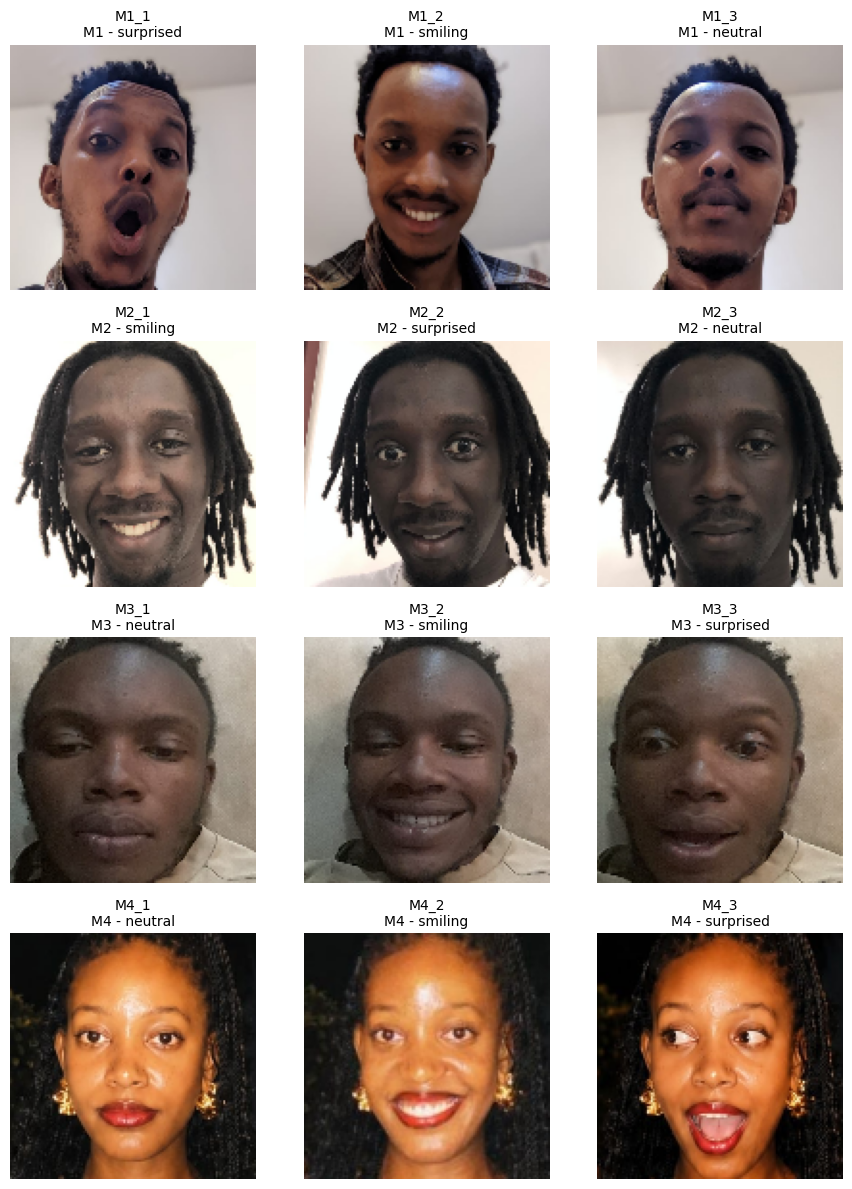

In [3]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

STANDARD_SIZE = (128, 128)

def detect_and_crop_face(name, img_bgr, margin_ratio=0.2):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    eq = cv2.equalizeHist(gray)
    faces = face_cascade.detectMultiScale(eq, scaleFactor=1.05, minNeighbors=4, minSize=(60, 60))
    if len(faces) == 0:
        raise RuntimeError(f'No face detected for {name}')

    x, y, w, h = max(faces, key=lambda b: b[2] * b[3])
    mx, my = int(w * margin_ratio), int(h * margin_ratio)
    x0, y0 = max(0, x - mx), max(0, y - my)
    x1, y1 = min(img_bgr.shape[1], x + w + mx), min(img_bgr.shape[0], y + h + my)
    crop = img_bgr[y0:y1, x0:x1]
    return cv2.resize(crop, STANDARD_SIZE)

faces = {name: detect_and_crop_face(name, img) for name, img in raw_images.items()}
show_grid(faces, lambda n: f'{n}\n{IMAGE_META[n][0]} - {IMAGE_META[n][1]}')


## 3. Augmentations

We apply three augmentations to every cropped face, as suggested by the assignment (rotation, flipping, grayscale):
- **Rotation** by 15 degrees around the center
- **Horizontal flip**
- **Grayscale** conversion (kept as a 3-channel image so it flows through the same feature-extraction code as the color versions)

Demonstrated first on a single image, then applied to all 12.

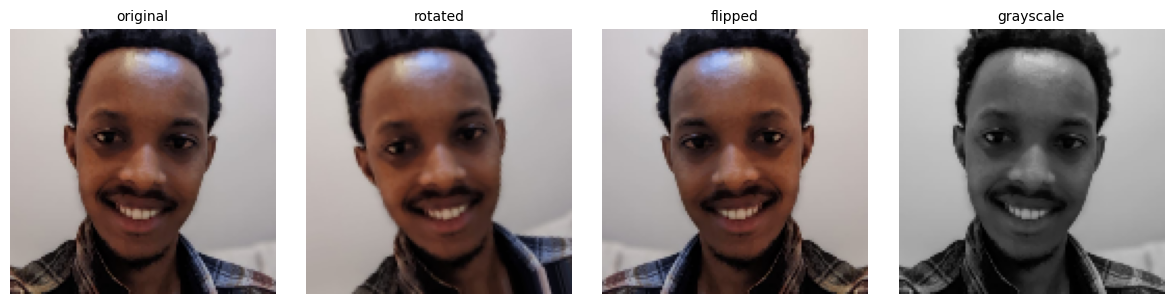

In [4]:
def augment_rotate(img, angle=15):
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REPLICATE)

def augment_flip(img):
    return cv2.flip(img, 1)

def augment_grayscale(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

AUGMENTATIONS = {
    'original': lambda img: img,
    'rotated': augment_rotate,
    'flipped': augment_flip,
    'grayscale': augment_grayscale,
}

# demo on one sample image
demo_name = 'M1_2'
demo_versions = {aug_name: fn(faces[demo_name]) for aug_name, fn in AUGMENTATIONS.items()}
show_grid(demo_versions, lambda n: n, ncols=4)


In [5]:
augmented_faces = {}
for name, face_img in faces.items():
    for aug_name, fn in AUGMENTATIONS.items():
        augmented_faces[f'{name}__{aug_name}'] = fn(face_img)

print('Total images after augmentation:', len(augmented_faces))


Total images after augmentation: 48


## 4. Feature extraction

For each image (original + augmented versions) we extract:
- **Pixel embedding**: the face resized to 32x32 grayscale, flattened and normalized to [0,1] (1024 values) — a simple embedding that preserves spatial layout, which histograms alone discard.
- **Grayscale histogram**: 32 bins, normalized.
- **Color histograms**: 32 bins per B/G/R channel, normalized.
- **Summary stats**: mean intensity, std intensity, edge density (fraction of Canny edge pixels).

These are saved with metadata (`member`, `expression`, `augmentation`, `source_file`) into `image_features.csv`.

In [6]:
def extract_features(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    embed = cv2.resize(gray, (32, 32)).flatten().astype(np.float32) / 255.0

    gray_hist = cv2.calcHist([gray], [0], None, [32], [0, 256]).flatten()
    gray_hist = gray_hist / (gray_hist.sum() + 1e-8)

    color_hists = []
    for ch in range(3):
        h = cv2.calcHist([img_bgr], [ch], None, [32], [0, 256]).flatten()
        color_hists.append(h / (h.sum() + 1e-8))

    edges = cv2.Canny(gray, 100, 200)
    edge_density = np.mean(edges > 0)

    features = {}
    for i, v in enumerate(embed):
        features[f'embed_{i}'] = v
    for i, v in enumerate(gray_hist):
        features[f'gray_hist_{i}'] = v
    for ch_name, hist in zip(['b', 'g', 'r'], color_hists):
        for i, v in enumerate(hist):
            features[f'{ch_name}_hist_{i}'] = v
    features['mean_intensity'] = float(np.mean(gray))
    features['std_intensity'] = float(np.std(gray))
    features['edge_density'] = float(edge_density)
    return features

rows = []
for key, img in augmented_faces.items():
    name, aug_name = key.split('__')
    member, expression = IMAGE_META[name]
    feats = extract_features(img)
    row = {'source_file': name, 'member': member, 'expression': expression, 'augmentation': aug_name}
    row.update(feats)
    rows.append(row)

image_features = pd.DataFrame(rows)
print('image_features shape:', image_features.shape)
image_features.head()


image_features shape: (48, 1159)


,source_file,member,expression,augmentation,embed_0,embed_1,embed_2,embed_3,embed_4,embed_5,...,r_hist_25,r_hist_26,r_hist_27,r_hist_28,r_hist_29,r_hist_30,r_hist_31,mean_intensity,std_intensity,edge_density
0,M1_1,M1,surprised,original,0.713726,0.705882,0.705882,0.709804,0.709804,0.713726,...,0.061707,0.025879,0.063110,0.014771,0.000427,0.0,0.0,136.071777,63.379555,0.075500
1,M1_1,M1,surprised,rotated,0.713726,0.713726,0.717647,0.721569,0.725490,0.725490,...,0.070312,0.022827,0.079285,0.013367,0.000305,0.0,0.0,138.172546,63.254661,0.063721
2,M1_1,M1,surprised,flipped,0.631373,0.639216,0.643137,0.647059,0.654902,0.662745,...,0.061707,0.025879,0.063110,0.014771,0.000427,0.0,0.0,136.071777,63.379555,0.075256
3,M1_1,M1,surprised,grayscale,0.713726,0.705882,0.705882,0.709804,0.709804,0.713726,...,0.036499,0.061768,0.029175,0.005066,0.000000,0.0,0.0,136.071777,63.379555,0.075500
4,M1_2,M1,smiling,original,0.807843,0.811765,0.815686,0.823529,0.827451,0.827451,...,0.072815,0.051270,0.002380,0.000000,0.000000,0.0,0.0,113.790466,69.628604,0.087158


## 5. Save extracted features

In [7]:
out_path = os.path.join(DATA_DIR, 'image_features.csv')
image_features.to_csv(out_path, index=False)
print('Saved', out_path, 'with shape', image_features.shape)
image_features[['source_file', 'member', 'expression', 'augmentation', 'mean_intensity', 'std_intensity', 'edge_density']].head(12)


Saved ../data/processed\image_features.csv with shape (48, 1159)


,source_file,member,expression,augmentation,mean_intensity,std_intensity,edge_density
0,M1_1,M1,surprised,original,136.071777,63.379555,0.075500
1,M1_1,M1,surprised,rotated,138.172546,63.254661,0.063721
2,M1_1,M1,surprised,flipped,136.071777,63.379555,0.075256
3,M1_1,M1,surprised,grayscale,136.071777,63.379555,0.075500
4,M1_2,M1,smiling,original,113.790466,69.628604,0.087158
5,M1_2,M1,smiling,rotated,112.453003,69.337977,0.073120
6,M1_2,M1,smiling,flipped,113.790466,69.628604,0.087219
7,M1_2,M1,smiling,grayscale,113.790466,69.628604,0.087158
8,M1_3,M1,neutral,original,139.491821,69.672805,0.073608
9,M1_3,M1,neutral,rotated,139.743408,69.456636,0.068970
